# Data

The raw network packets of the UNSW-NB 15 dataset was created by the IXIA PerfectStorm tool in the Cyber Range Lab of UNSW Canberra for generating a hybrid of real modern normal activities and synthetic contemporary attack behaviors. The tcpdump tool was utilized to capture 100 GB of the raw traffic (e.g., Pcap files). This dataset has nine types of attacks, namely, Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode and Worms. The Argus, Bro-IDS tools are used and twelve algorithms are developed to generate totally 49 features with the class label. These features are described in the UNSW-NB15_features.csv file.

source:
https://research.unsw.edu.au/projects/unsw-nb15-dataset


# Index

1. Data Inspection
2. Data Preprocessing for EDA
3. Exploratory Data Analysis (EDA)

# 1. Data Inspection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


In [2]:
NB15_features = pd.read_csv('NUSW-NB15_features.csv', encoding='cp1252')
NB15_features

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [3]:
df = pd.read_csv('UNSW_NB15_training-set.csv')

In [4]:
df

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,13,24,0,0,0,24,24,0,Generic,1
175337,175338,0.505762,tcp,-,FIN,10,8,620,354,33.612649,...,1,2,0,0,0,1,1,0,Shellcode,1
175338,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,3,13,0,0,0,3,12,0,Generic,1
175339,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,14,30,0,0,0,30,30,0,Generic,1


In [5]:
df.columns

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [7]:
df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


In [8]:
df.describe(include='object')

,proto,service,state,attack_cat
count,175341,175341,175341,175341
unique,133,13,9,10
top,tcp,-,INT,Normal
freq,79946,94168,82275,56000


# 2. Data Preprocessing for EDA

In [9]:
df.isna().sum()

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

In [10]:
df.dropna(inplace=True)

In [11]:
df.isna().sum().sum()

np.int64(0)

In [12]:
df.drop(['id'], axis=1, inplace=True)

In [13]:
# Replacing '-' in state and service for 'other'
df['state'] = df['state'].replace('-','other')
df['service'] = df['service'].replace('-','other')

# 3. EDA

In [14]:
counts = df['label'].value_counts()
fig = px.pie(counts, values=counts.values, names=counts.index, title='Distribution of Label')
fig.show()

Grouping by attack category

In [15]:
df[df['attack_cat']!='normal'].groupby('attack_cat').size()

attack_cat
Analysis           2000
Backdoor           1746
DoS               12264
Exploits          33393
Fuzzers           18184
Generic           40000
Normal            56000
Reconnaissance    10491
Shellcode          1133
Worms               130
dtype: int64

We need to group Backdoor and Backdoors into a single category

In [16]:
df['attack_cat'] = df['attack_cat'].apply(lambda item: 'Backdoor' if item =='Backdoors' else item)

In [17]:
attack_by_cat = df[df['attack_cat']!='normal'].groupby('attack_cat').size().reset_index(name='counts')
attack_by_cat

,attack_cat,counts
0,Analysis,2000
1,Backdoor,1746
2,DoS,12264
3,Exploits,33393
4,Fuzzers,18184
5,Generic,40000
6,Normal,56000
7,Reconnaissance,10491
8,Shellcode,1133
9,Worms,130


Distribution of attacks by category

In [18]:
attack_by_cat = df[df['attack_cat']!='normal'].groupby('attack_cat').size().reset_index(name='counts').sort_values(by='counts', ascending = False)
fig = px.bar(attack_by_cat, x='attack_cat', y='counts', title='Distribution of attack categories')
fig.show()

Distribution of source bytes by attack category

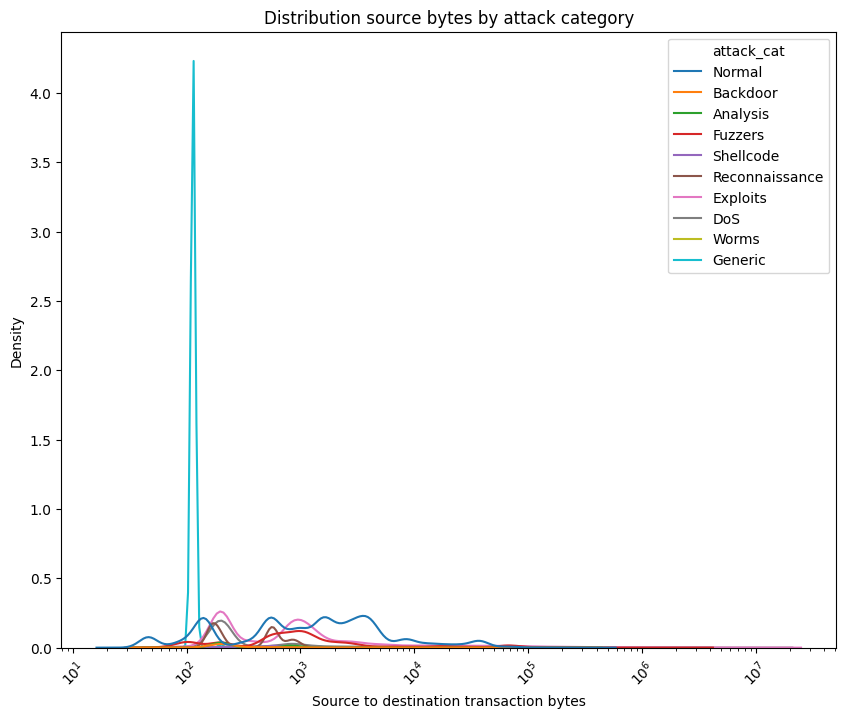

In [19]:
plt.figure(figsize=(10,8))
ax = sns.kdeplot(x='sbytes',hue='attack_cat',log_scale=True,data=df[df['attack_cat']!='normal'])
ax.set_title('Distribution source bytes by attack category')
ax.set_xlabel('Source to destination transaction bytes')
ax.set_ylabel('Density')
plt.xticks(rotation=45)
plt.show()

Most used services by attack category

In [20]:
df_attacks_cat_services = df[(df['attack_cat']!='normal')].groupby(['attack_cat','service']).size().reset_index(name='Count')

In [21]:
# Create a 3x3 subplot grid
fig = make_subplots(rows=3, cols=3,
                    subplot_titles=('Category: Analysis', 'Category: Backdoor', 'Category: DoS',
                                    'Category: Exploits', 'Category: Fuzzers', 'Category: Generic',
                                    'Category: Reconnaissance', 'Category: Shellcode', 'Category: Worms'))

# Create a list of attack categories to loop through
categories = ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']

# Define row and column positions for each plot
positions = [(1,1), (1,2), (1,3), (2,1), (2,2), (2,3), (3,1), (3,2), (3,3)]

# Loop through the categories and create a bar plot for each one
for i, category in enumerate(categories):
    # Filter the dataframe for each attack category
    df_filtered = df_attacks_cat_services[df_attacks_cat_services['attack_cat'] == category]

    # Add bar plot to the subplot
    fig.add_trace(go.Bar(x=df_filtered['service'], y=df_filtered['Count'], name=category,
                         marker_color=px.colors.qualitative.Plotly[i]),
                  row=positions[i][0], col=positions[i][1])

# Update layout
fig.update_layout(height=900, width=900, title_text="Service Counts by Attack Categories", showlegend=False)

# Update x-axis for all subplots
fig.update_xaxes(tickangle=90)

# Show the figure
fig.show()


Top-5 protocols used by attack category

In [22]:
df_attacks_cat_proto = df[(df['attack_cat']!='normal')].groupby(['attack_cat','proto']).size().reset_index(name='Count')

In [23]:
# Create a 3x3 subplot grid
fig = make_subplots(rows=3, cols=3,
                    subplot_titles=('Category: Analysis', 'Category: Backdoor', 'Category: DoS',
                                    'Category: Exploits', 'Category: Fuzzers', 'Category: Generic',
                                    'Category: Reconnaissance', 'Category: Shellcode', 'Category: Worms'))

# Create a list of attack categories to loop through
categories = ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']

# Define row and column positions for each plot
positions = [(1,1), (1,2), (1,3), (2,1), (2,2), (2,3), (3,1), (3,2), (3,3)]

# Loop through the categories and create a bar plot for each one (top 5 protocols)
for i, category in enumerate(categories):
    # Filter the dataframe for each attack category and take the top 5 protocols
    df_filtered = df_attacks_cat_proto[df_attacks_cat_proto['attack_cat'] == category][:5]

    # Add bar plot to the subplot
    fig.add_trace(go.Bar(x=df_filtered['proto'], y=df_filtered['Count'], name=category,
                         marker_color=px.colors.qualitative.Plotly[i]),
                  row=positions[i][0], col=positions[i][1])

# Update layout
fig.update_layout(height=900, width=900, title_text="Top 5 Protocols by Attack Categories", showlegend=False)

# Update x-axis for all subplots
fig.update_xaxes(tickangle=90)

# Show the figure
fig.show()


Distribution of states by attack category

In [24]:
df_attacks_cat_state = df[(df['attack_cat']!='normal')].groupby(['attack_cat','state']).size().reset_index(name='Count')

In [25]:
# Create a 3x3 subplot grid
fig = make_subplots(rows=3, cols=3,
                    subplot_titles=('Category: Analysis', 'Category: Backdoor', 'Category: DoS',
                                    'Category: Exploits', 'Category: Fuzzers', 'Category: Generic',
                                    'Category: Reconnaissance', 'Category: Shellcode', 'Category: Worms'))

# List of attack categories
categories = ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']

# Define the row and column positions for the plots
positions = [(1,1), (1,2), (1,3), (2,1), (2,2), (2,3), (3,1), (3,2), (3,3)]

# Loop through the attack categories and create a bar plot for each one
for i, category in enumerate(categories):
    # Filter the dataframe for each attack category
    df_filtered = df_attacks_cat_state[df_attacks_cat_state['attack_cat'] == category]

    # Add bar plot to the subplot
    fig.add_trace(go.Bar(x=df_filtered['state'], y=df_filtered['Count'], name=category,
                         marker_color=px.colors.qualitative.Plotly[i]),
                  row=positions[i][0], col=positions[i][1])

# Update the layout of the entire figure
fig.update_layout(height=900, width=900, title_text="Attack Counts by State and Category", showlegend=False)

# Rotate x-axis labels for better readability
fig.update_xaxes(tickangle=90)

# Show the plot
fig.show()


**Summary of EDA:**


*   The distribution of attacks types is not uniform, most of them are generic.
*   The distributions of source bytes sent by attack type follow a similar trend, there are not noticeable differences between them.
*   Most of the attacks use HTTP service (not considering 'other' category).
*   3pc and argus are protocols commonly used in distributed computing environments. Both are used by the majority of attacking types along with TCP and UDP






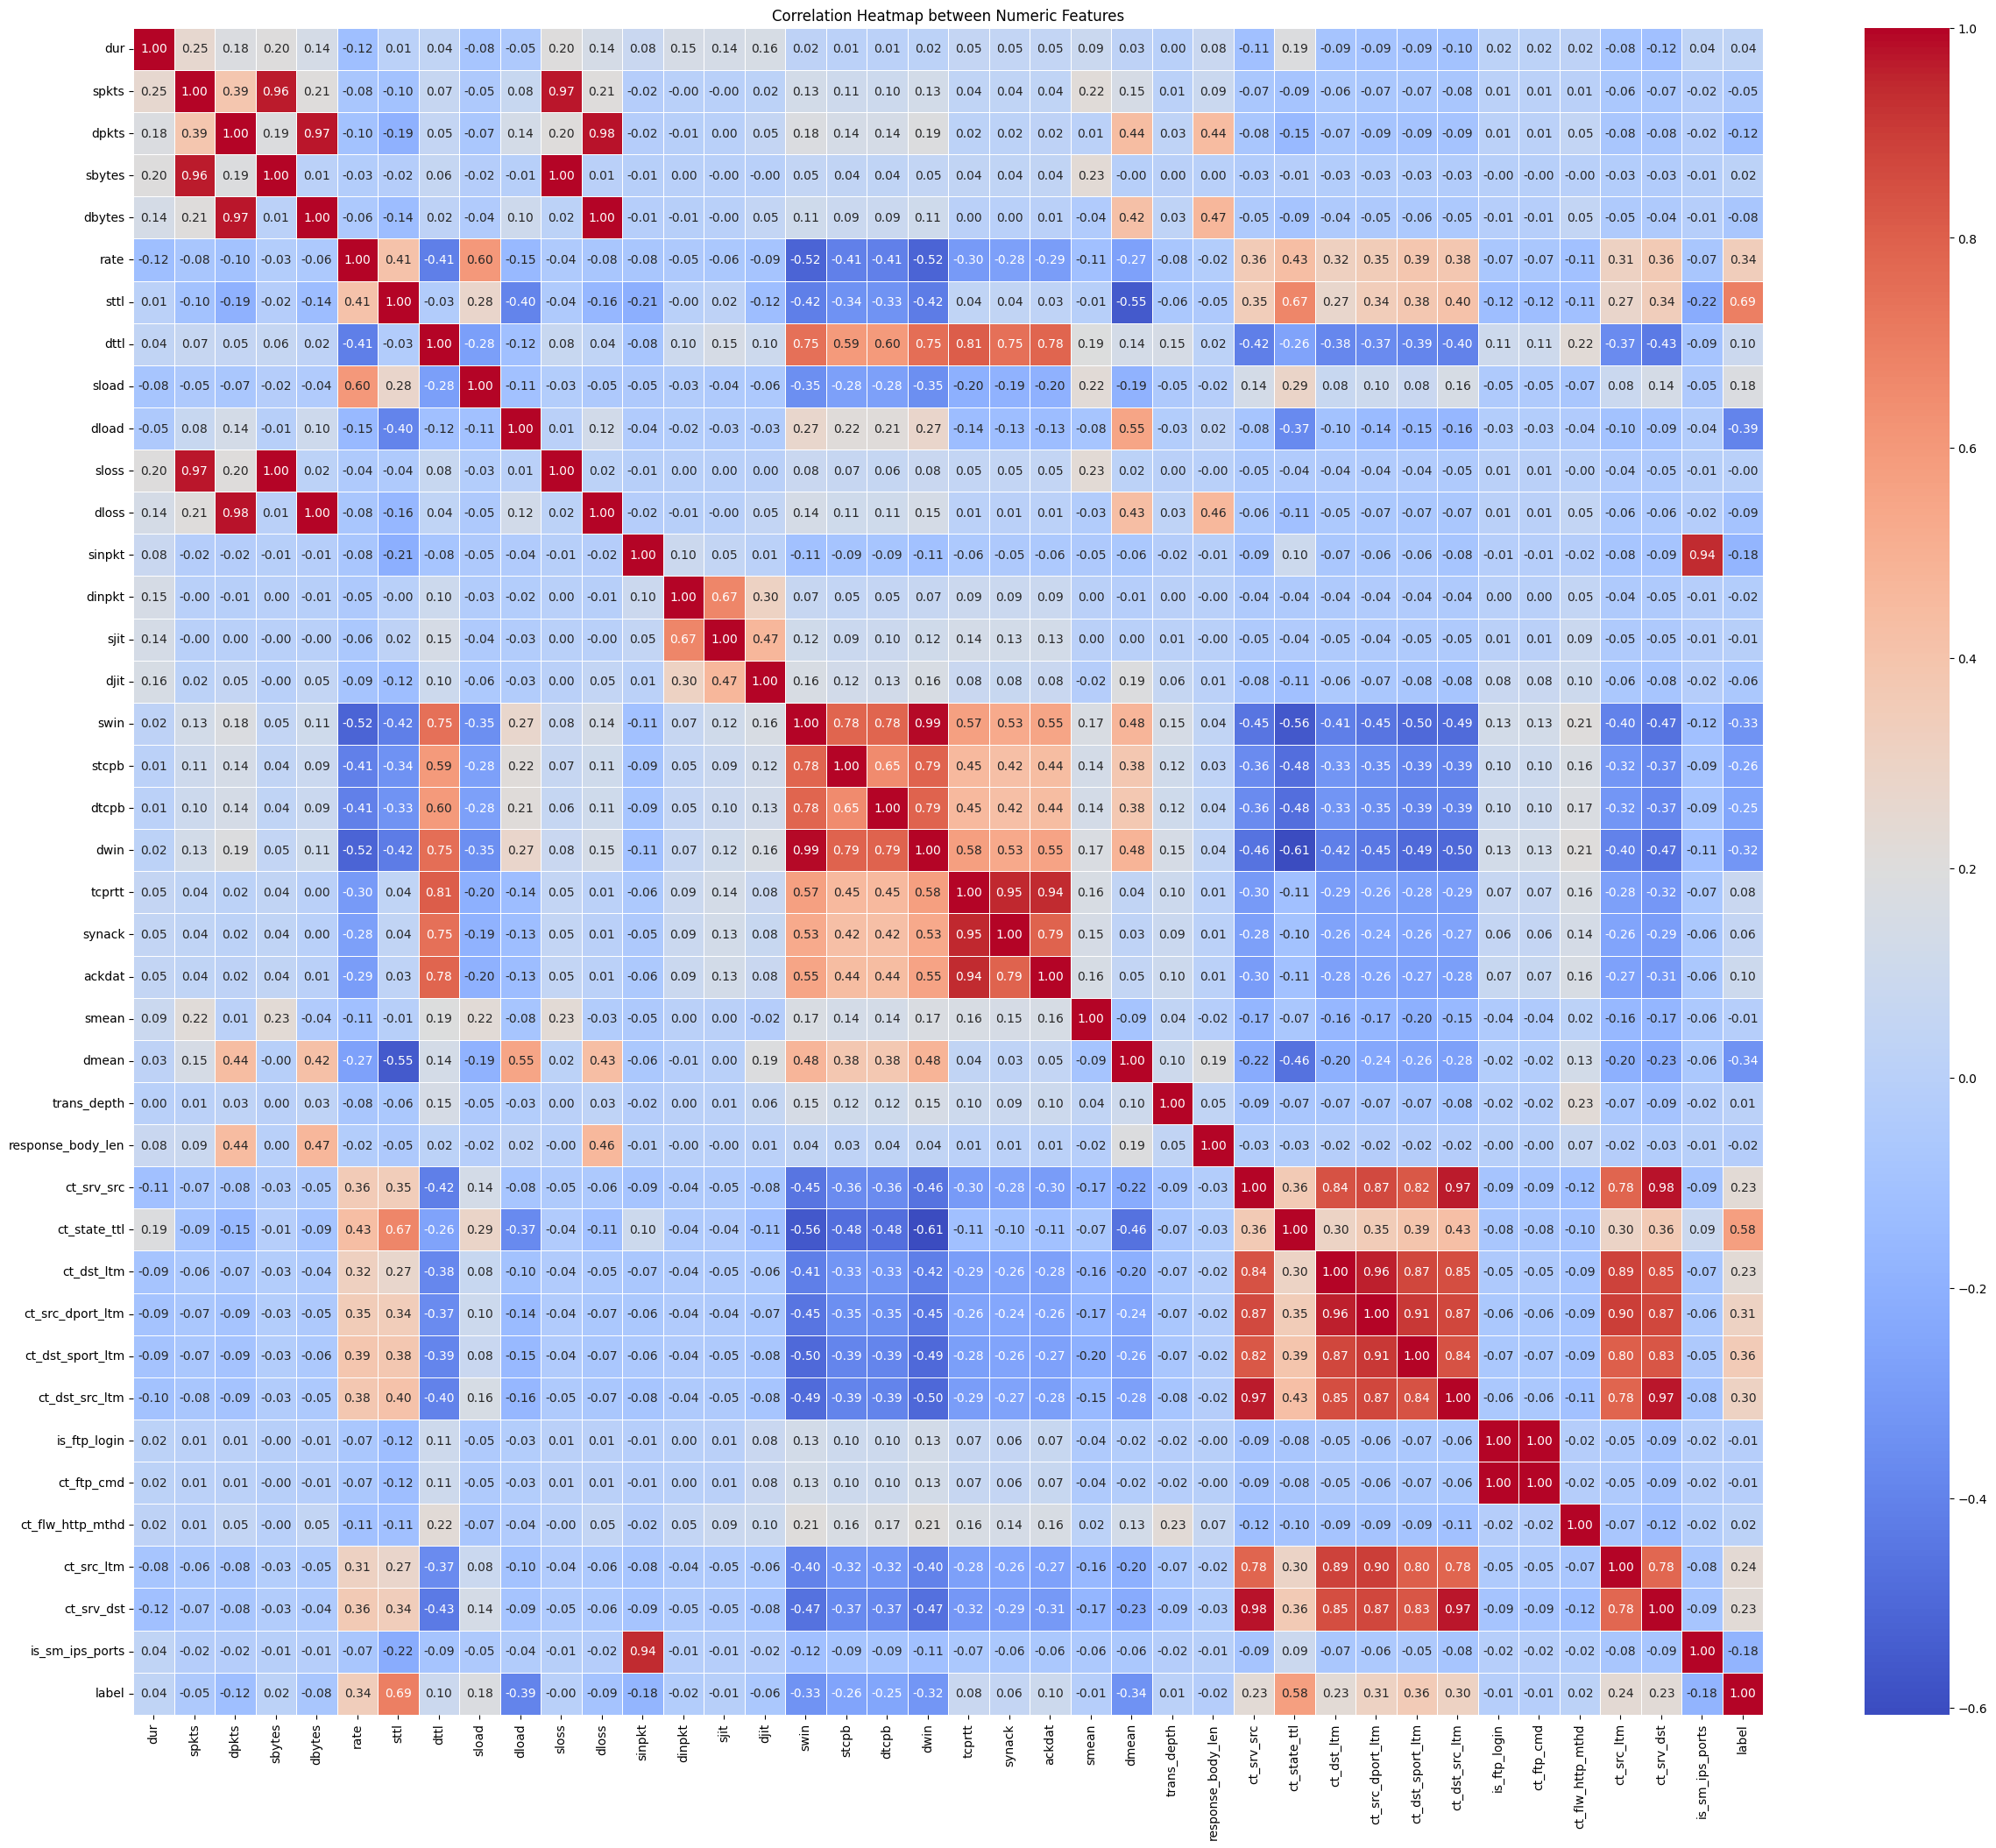

In [26]:
numerical_columns = [col for col in df.columns if df[col].dtypes != "object"]
# Calculate the correlation matrix for numerical columns
corr = df[numerical_columns].corr()

plt.figure(figsize=(30, 25))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap between Numeric Features')
plt.show()

In [27]:
corr_matrix = df[numerical_columns].corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = upper_triangle.stack().reset_index()
high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] > 0.80]
high_corr_pairs

,Feature 1,Feature 2,Correlation
40,spkts,sbytes,0.963791
47,spkts,sloss,0.971069
78,dpkts,dbytes,0.971907
85,dpkts,dloss,0.978636
120,sbytes,sloss,0.996109
156,dbytes,dloss,0.996504
264,dttl,tcprtt,0.807341
427,sinpkt,is_sm_ips_ports,0.941319
506,swin,dwin,0.990140
590,tcprtt,synack,0.949468
